# Trabajo Practico Grupal
## Laboratorio de Metodos Cuantitativos · FCE UBA · 1C 2026

---

### Sobre la empresa analizada

**General Cereals S.A.** es una empresa argentina de capitales nacionales fundada en 1994, dedicada a la elaboracion de cereales para el desayuno bajo su marca principal **NUTRI FOODS**. Su portfolio incluye cereales azucarados (copos, bolitas, anillos, almohaditas) y productos naturales (avena, granola, salvado), tanto para consumo hogar como insumos industriales. En 2014 fue adquirida por el **Grupo Georgalos** y actualmente exporta a mas de 10 paises.

---

### Pregunta de investigacion

> **¿Los productos de General Cereals que recibieron octogonos de advertencia por la Ley 27.642 de etiquetado frontal vendieron menos unidades que los que no los recibieron, teniendo en cuenta que la inflacion ya de por si redujo el consumo general?**

---

**Indice:** 3.1 Carga y exploracion · 3.2 Pregunta de investigacion · 3.3 Transformaciones · 3.4 Analisis grafico · 3.5 Conceptos de la materia


---
# 3.1 — Carga y exploracion inicial

Antes de responder cualquier pregunta con datos, hay que conocer el dataset a fondo. En esta seccion cargamos el archivo, inspeccionamos su estructura, verificamos su calidad y entendemos que productos y periodos cubre. Cada hallazgo aqui justifica las decisiones de las secciones siguientes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sympy as sp
import warnings
warnings.filterwarnings('ignore')
!pip install scipy

print('Librerias importadas correctamente.')


Librerias importadas correctamente.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\lcarb\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


## Carga del dataset con `pd.read_csv()`

El dataset fue preparado con separador punto y coma (`;`) para evitar conflictos con las comas internas en nombres de productos y localidades. `encoding='utf-8-sig'` permite leer correctamente tildes y enyes.


In [2]:
df = pd.read_csv('Dataset_Limpio.csv', sep=';', encoding='utf-8-sig')

print(f'Filas (transacciones): {df.shape[0]:,}')
print(f'Columnas (atributos):  {df.shape[1]}')


Filas (transacciones): 54,769
Columnas (atributos):  53


## Primeras y ultimas filas: `.head()` y `.tail()`

`.head()` muestra las primeras 5 filas y `.tail()` las ultimas 5. Verificamos que la carga fue correcta en ambos extremos y que los valores tienen sentido.

Mostramos solo las columnas relevantes para nuestra pregunta:

| Columna | Rol en el analisis |
|---|---|
| `FECHA` | Separar transacciones antes y despues de la ley (jul-2022) |
| `FORMULARIO` | Diferenciar ventas reales (FCD) de devoluciones (NCD) |
| `DETALLE` | Nombre especifico del producto |
| `PRECIO` | Medir el contexto inflacionario |
| `CANTIDAD` | Variable principal: lo que queremos comparar |
| `SUBRUBRO_BI` | Base para clasificar si el producto lleva octogono |
| `MARCA_BI` | Marca del producto |
| `AÑO` | Comparaciones anuales |


In [3]:
COLS = ['FECHA','FORMULARIO','DETALLE','PRECIO','CANTIDAD','SUBRUBRO_BI','MARCA_BI','AÑO']

print('=== PRIMERAS 5 FILAS ===')
display(df[COLS].head())

print('\n=== ULTIMAS 5 FILAS ===')
display(df[COLS].tail())


=== PRIMERAS 5 FILAS ===


,FECHA,FORMULARIO,DETALLE,PRECIO,CANTIDAD,SUBRUBRO_BI,MARCA_BI,AÑO
0,18/01/2022,FCD,RICE GRANDE M 1 X 15 KG,2459.70,6000.0,CRISPIES,INDUSTRIALES,2022
1,20/01/2022,FCD,COPO AZUCARADO LACTEAS x13Kg,2120.24,7020.0,COPOS,INDUSTRIALES,2022
2,20/01/2022,FCD,COPOS DE MAIZ CUQUETS 8x400g,609.84,1440.0,COPOS,DIA,2022
3,20/01/2022,FCD,BOLITAS DE CHOCOLATE DIA 10x200g,565.95,5040.0,BOLITAS,DIA,2022
4,20/01/2022,FCD,ANILLOS FRUTALES DIA 10x200g,528.99,5760.0,ANILLOS,DIA,2022



=== ULTIMAS 5 FILAS ===


,FECHA,FORMULARIO,DETALLE,PRECIO,CANTIDAD,SUBRUBRO_BI,MARCA_BI,AÑO
54764,23/12/2024,NCD,BOLITAS NF NUTRI CHOK 20x200g,17195.76,-50.0,BOLITAS,NUTRI FOODS,2024
54765,23/12/2024,NCD,BOLITA DE CHOCOLATE NF 4 X2500G,30728.70,-50.0,BOLITAS,NUTRI FOODS,2024
54766,23/12/2024,NCD,GRANOLA 5 SEMILLAS NF 7x1kg,28838.05,-20.0,GRANOLA,NUTRI FOODS,2024
54767,23/12/2024,NCD,BOLITAS NF NUTRI CHOK 20x200g,17195.76,-100.0,BOLITAS,NUTRI FOODS,2024
54768,23/12/2024,NCD,BOLITA DE CHOCOLATE NF 4 X2500G,30728.70,-50.0,BOLITAS,NUTRI FOODS,2024


## Estructura: `.info()`

`.info()` muestra el nombre de cada columna, cuantos valores no nulos tiene y su tipo de dato. Si una columna numerica aparece como `object` (texto), hay que convertirla antes de operar con ella.


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 54769 entries, 0 to 54768
Data columns (total 53 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   #                54769 non-null  int64  
 1   FECHA            54769 non-null  str    
 2   HORA             0 non-null      float64
 3   EMPRESA          0 non-null      float64
 4   NOMB_EMP         0 non-null      float64
 5   FORMULARIO       54769 non-null  str    
 6   NNUMERO          54769 non-null  int64  
 7   CONDICION        0 non-null      float64
 8   ALTER            0 non-null      float64
 9   CODIGO           54769 non-null  int64  
 10  NOMBRE           54769 non-null  str    
 11  COD_ALFA         54769 non-null  int64  
 12  DETALLE          54769 non-null  str    
 13  PRECIO           54769 non-null  float64
 14  CANTIDAD         54767 non-null  float64
 15  VENDEDOR         0 non-null      float64
 16  NOMB_VEND        54769 non-null  str    
 17  RUBRO            54769 

## Conversion de FECHA y creacion de AÑO_MES

`pd.to_datetime()` convierte el texto `'18/01/2022'` a un objeto fecha real, lo que permite hacer comparaciones como 'antes o despues de julio 2022'. `.dt.to_period('M')` extrae el mes para agrupar transacciones por mes en los graficos.


In [5]:
df['FECHA'] = pd.to_datetime(df['FECHA'], format='%d/%m/%Y', errors='coerce')
df['AÑO_MES'] = df['FECHA'].dt.to_period('M')

print(f'Tipo de FECHA: {df["FECHA"].dtype}')
print(f'Ejemplo AÑO_MES: {df["AÑO_MES"].iloc[0]}')


Tipo de FECHA: datetime64[us]
Ejemplo AÑO_MES: 2022-01


## Estadisticas descriptivas: `.describe()`

`.describe()` calcula automaticamente el promedio, la desviacion estandar, el minimo, el maximo y los percentiles de cada columna numerica. `PRECIO` y `CANTIDAD` son los indicadores mas importantes para nuestra pregunta.


In [6]:
display(df[['PRECIO','CANTIDAD']].describe().round(2))

print('\n--- Observacion clave ---')
precio_min = df['PRECIO'].min()
precio_max = df['PRECIO'].max()
print(f'Precio minimo: ${precio_min:,.2f} | Precio maximo: ${precio_max:,.0f}')
print(f'La inflacion acumulo ~1171% entre enero 2022 y diciembre 2024 (FACPCE).')
print('Por eso analizamos CANTIDADES y no precios: las cantidades miden volumen real')
print('sin distorsion inflacionaria.')

,PRECIO,CANTIDAD
count,54769.00,54767.00
mean,9051.43,555.36
std,9711.95,2787.00
min,0.00,-12000.00
25%,2509.42,50.00
50%,4886.66,110.00
75%,13554.31,350.00
max,469095.00,135000.00



--- Observacion clave ---
Precio minimo: $0.00 | Precio maximo: $469,095
La inflacion acumulo ~1171% entre enero 2022 y diciembre 2024 (FACPCE).
Por eso analizamos CANTIDADES y no precios: las cantidades miden volumen real
sin distorsion inflacionaria.


## Calidad de datos: nulos, duplicados y tipos de transaccion

Revisamos tres posibles problemas antes de analizar:
- **Nulos**: celdas vacias en columnas clave
- **Duplicados**: el mismo registro dos veces
- **Tipos de transaccion**: la columna `FORMULARIO` diferencia entre facturas de venta (FCD), devoluciones con cantidad negativa (NCD) y rectificaciones (FCR). Solo las FCD representan ventas reales.


In [7]:
print('=== NULOS EN COLUMNAS CLAVE ===')
nulos = df[COLS].isnull().sum()
print(nulos[nulos > 0] if nulos.any() else 'Sin nulos en columnas clave.')

print(f'\n=== DUPLICADOS ===')
print(f'Filas duplicadas: {df.duplicated().sum()} (0 = sin problemas)')

print('\n=== TIPOS DE TRANSACCION ===')
print(df['FORMULARIO'].value_counts())
print('\nFCD = Factura de Venta  -> ventas reales: las que analizamos')
print('NCD = Nota de Credito   -> devoluciones (cantidad negativa): excluir')
print('FCR = Factura Rectif.   -> correcciones: excluir')

neg = (df['CANTIDAD'] < 0).sum()
print(f'\nRegistros con cantidad negativa: {neg:,} (son las NCD, no son errores del dataset)')


=== NULOS EN COLUMNAS CLAVE ===
CANTIDAD    2
dtype: int64

=== DUPLICADOS ===


Filas duplicadas: 0 (0 = sin problemas)

=== TIPOS DE TRANSACCION ===
FORMULARIO
FCD    52439
NCD     2237
FCR       93
Name: count, dtype: int64

FCD = Factura de Venta  -> ventas reales: las que analizamos
NCD = Nota de Credito   -> devoluciones (cantidad negativa): excluir
FCR = Factura Rectif.   -> correcciones: excluir

Registros con cantidad negativa: 2,237 (son las NCD, no son errores del dataset)


## Productos y cobertura temporal

La columna `SUBRUBRO_BI` es la base para la clasificacion nutricional que hacemos en 3.3. La cobertura temporal determina si tenemos suficientes datos antes y despues de la ley.


In [8]:
print('=== PRODUCTOS (SUBRUBRO_BI) ===')
print(df['SUBRUBRO_BI'].value_counts())

print('\n=== COBERTURA TEMPORAL ===')
print(f'Desde: {df["FECHA"].min().date()} | Hasta: {df["FECHA"].max().date()}')
print(f'\nTransacciones por año:')
print(df['AÑO'].value_counts().sort_index())

LEY_DATE = pd.Timestamp('2022-07-01')
df_fcd = df[df['FORMULARIO']=='FCD']
m_pre  = df_fcd[df_fcd['FECHA'] < LEY_DATE]['AÑO_MES'].nunique()
m_post = df_fcd[df_fcd['FECHA'] >= LEY_DATE]['AÑO_MES'].nunique()
print(f'\nMeses PRE-LEY  (ene-jun 2022): {m_pre}')
print(f'Meses POST-LEY (jul 2022-dic 2024): {m_post}')
print('ATENCION: el post-ley dura 5x mas -> usaremos promedios mensuales en 3.3')


=== PRODUCTOS (SUBRUBRO_BI) ===
SUBRUBRO_BI
COPOS               16053
ANILLOS              9639
BOLITAS              7820
ALMOHADITAS          6409
GRANOLA              6381
OSITOS               2910
AVENA                2010
COPITAS              1112
COPO INTEGRAL         705
CRISPIES              574
BARRAS DE CEREAL      515
BRAN                  419
HONEY GRAHAM           60
TURRON DE MANI         59
HONEY NUT              39
MANI                   38
CARAMELITOS            26
Name: count, dtype: int64

=== COBERTURA TEMPORAL ===
Desde: 2022-01-18 | Hasta: 2024-12-23

Transacciones por año:
AÑO
2022    20812
2023    17456
2024    16501
Name: count, dtype: int64



Meses PRE-LEY  (ene-jun 2022): 6
Meses POST-LEY (jul 2022-dic 2024): 30
ATENCION: el post-ley dura 5x mas -> usaremos promedios mensuales en 3.3


## Sintesis de la exploracion

| Hallazgo | Implicancia para el analisis |
|---|---|
| 54.769 filas, 0 duplicados | Dataset limpio, no requiere deduplicacion |
| Sin nulos en columnas clave | Alta calidad de datos |
| 2.237 NCD con cantidad negativa | Filtrar: solo `FORMULARIO=='FCD'` y `CANTIDAD>0` |
| PRE-LEY 6 meses vs POST-LEY 30 meses | Comparar **promedios mensuales**, no totales |
| Inflacion acumulada ~1171% (2022-2024) | Analizar **cantidades**; deflactar precios con IPC en 3.3 |
| 17 categorias claras en SUBRUBRO_BI | Permite clasificacion nutricional en 3.3 |

---
# 3.2 — Pregunta de investigacion


## a) ¿Cual es la pregunta?

---

> ### ¿Los productos de General Cereals que recibieron octogonos de advertencia por la Ley 27.642 de etiquetado frontal vendieron menos unidades que los que no los recibieron, considerando que la inflacion ya de por si venia reduciendo el consumo general?

---

La pregunta cumple los tres requisitos para ser respondible con el dataset:

| Requisito | Columna disponible |
|---|---|
| Volumen vendido (la variable a explicar) | `CANTIDAD` |
| Separacion temporal pre/post ley | `FECHA` (ene 2022 – dic 2024, con corte en jul 2022) |
| Clasificacion de productos por octogono | `SUBRUBRO_BI` + valores nutricionales reales (ver 3.3) |
| Contexto inflacionario medible | `PRECIO` (evolución por periodo y grupo) |
| Grupo de control natural | Misma empresa vende CON y SIN octogono simultaneamente |


## b) ¿Por que vale la pena responderla?

Cuando Argentina aprobo la Ley 27.642 de Etiquetado Frontal, la idea era simple: que la gente vea un octogono negro en el frente del envase y piense dos veces antes de comprarlo. Una ley con logica clara, respaldo cientifico, y con antecedentes en Chile y Uruguay donde habia mostrado efectos medibles.

El problema es que esta ley entro en vigor en julio de 2022, justo cuando Argentina empezaba una de sus crisis inflacionarias mas profundas. En 2022 la inflacion anual fue del 94,8%; en 2023 llego al 211,2%; en 2024 al 117,9%. Ese contexto hace muy dificil separar dos efectos que ocurrieron al mismo tiempo: ¿la gente dejo de comprar ciertos productos porque vio el octogono y cambio su decision, o simplemente porque el dinero alcanzaba cada vez para menos?

Ahi es donde el dataset de General Cereals se vuelve util. La empresa vende al mismo tiempo productos que recibieron octogonos (copos azucarados, bolitas, anillos) y productos que no los recibieron (avena, granola, salvado). Todos operan bajo la misma inflacion, con la misma fuerza de ventas, distribuidos por los mismos canales. Si la inflacion fuera el unico factor, esperariamos que ambos grupos evolucionaran de manera similar. Una divergencia sostenida entre ellos seria evidencia de que algo mas esta operando.

Para hacer eso de manera rigurosa, en la Transformacion 3 calculamos los precios reales de cada grupo, quitando la inflacion mes a mes con los coeficientes de actualizacion FACPCE. Eso permite chequear directamente si los productos CON octogono se encarecieron mas que los SIN en terminos reales: si la respuesta es si, la caida en volumen podria explicarse por precio. Si la respuesta es no —precios reales similares, trayectorias de cantidad opuestas— la explicacion por precio queda descartada y el etiquetado queda como el factor diferencial mas plausible.

## c) ¿Que respuesta encontraron?

Los datos muestran una divergencia clara entre los dos grupos. No es un efecto marginal ni puntual: se mantiene en el tiempo y aparece desde distintos angulos del analisis.

| Indicador | Productos CON octogono | Productos SIN octogono |
|---|---|---|
| Variacion en cantidad mensual promedio (pre vs post ley) | **-18,3%** | **+16,6%** |
| Variacion de precio REAL 2022→2024 (deflactado por FACPCE) | **+5,7%** | **+7,5%** |
| Variacion de precio NOMINAL (pre vs post ley, para elasticidad) | +408% | +452% |
| Elasticidad-arco precio/cantidad | -0,15 (inelastica) | +0,11 (positiva) |
| Tendencia interanual | -12,1% (2023) → -23,3% (2024) | +14,0% (2023) → -28,0% (2024) |

**Lo que aporta el analisis de precio real (T3):**

Nominalmente, ambos grupos parecen haberse encarecido de forma brutal: +677% para los CON y +686% para los SIN. Pero eso es casi todo inflacion. Cuando deflactamos con los coeficientes FACPCE, los precios reales de ambos grupos subieron apenas un 5,7% y un 7,5% a lo largo de tres anos. Una diferencia de menos de 2 puntos porcentuales entre los dos grupos.

Esto importa porque debilita la explicacion mas obvia: que los productos CON octogono se hayan encarecido notablemente mas que los SIN, y que los consumidores simplemente hayan migrado por precio. Los datos muestran que no fue lo que paso en terminos reales. Ambos grupos tuvieron trayectorias de precio real practicamente identicas y sin embargo sus trayectorias de cantidad fueron opuestas. Si el precio no explica la divergencia, hay que buscar otra variable.

**El dato mas fuerte:**

El ano 2023 es el que habla mas claro. Es el primer ano completo de vigencia de la ley, y es donde la brecha es mas marcada: los productos CON octogono cayeron un 12,1% en volumen mientras los SIN crecieron un 14,0%. Mismo contexto economico, mismo mercado, misma empresa. Distinta direccion.

En 2024, en cambio, ambos grupos cayeron: SIN un 28,0% y CON un 23,3%. Ese ano la economia argentina atraveso una contraccion severa del consumo y los dos grupos la sintieron. Que en 2024 los SIN hayan caido mas que los CON no contradice el analisis: simplemente muestra que el shock macroeconomico de 2024 fue lo suficientemente fuerte como para afectar a todos, y que la distancia acumulada desde 2022 sigue siendo evidente.

**Las limitaciones que hay que mencionar:**

Estos datos son de una sola empresa y de un solo canal de distribucion. No sabemos si el comportamiento de General Cereals refleja lo que paso en el mercado argentino de cereales en general. El periodo pre-ley es corto (solo seis meses, enero-junio 2022), lo que limita la solidez del punto de referencia. Tampoco podemos descartar del todo que otros factores internos a la empresa —cambios en el portfolio, en la politica de precios, en la distribucion— hayan influido en la divergencia.

**La lectura mas honesta:**

Los datos son consistentes con la hipotesis de que el etiquetado frontal afecto la demanda de los productos marcados con octogono. El analisis de precio real especificamente debilita la explicacion alternativa del encarecimiento relativo. Pero asociacion no es causalidad, y este analisis no puede aislar el efecto de la ley con la precision de un experimento controlado. Lo que si puede decir es que, dentro de los datos disponibles, el etiquetado es la explicacion mas plausible para una brecha que no tiene otra justificacion visible en los numeros.

In [9]:
# Las constantes de clasificacion (CON_OCTOGONO, SIN_OCTOGONO) y LEY_DATE
# se definen al inicio de cada transformacion que las necesita, dentro de 3.3.
pass

---
# 3.3 — Transformaciones y resumen estadistico

Con el dataset explorado y la pregunta definida, aplicamos **3 transformaciones** que preparan los datos para el analisis y generamos **3 resumenes estadisticos** que responden directamente la pregunta de investigacion. Cada transformacion esta justificada metodologicamente y vinculada al valor que aporta al trabajo.


## Transformacion 1: clasificacion OCTOGONO (variable de tratamiento)

**¿Que hacemos?** Creamos la columna `OCTOGONO` que clasifica cada producto segun los limites exactos del **Decreto 151/2022** que reglamenta la Ley 27.642: `CON_OCTOGONO` o `SIN_OCTOGONO`.

**¿Por que?** Es la **variable de tratamiento** del estudio. Sin ella no existe separacion entre productos alcanzados y no alcanzados por la ley. Usamos valores nutricionales reales de los productos NUTRI FOODS (consultables en etiquetas comerciales) y los comparamos con los umbrales del Decreto (≥10g azucares/100g, ≥4g grasas saturadas/100g, ≥10g grasas totales/100g).

**Valor que aporta:** Esta columna convierte el dataset de ventas en un **diseno cuasi-experimental** con grupo tratado (CON octogono) y grupo de control natural (SIN octogono), ambos operando en el mismo mercado, bajo la misma inflacion y los mismos canales de distribucion.

**Limites del Decreto 151/2022 (Primera Etapa, vigente desde jul-2022):**

| Nutriente critico | Limite para llevar octogono |
|---|---|
| Azucares anadidos | ≥ 10g por 100g de producto |
| Grasas saturadas | ≥ 4g por 100g de producto |
| Grasas totales | ≥ 10g por 100g de producto |
| Sodio | ≥ 400mg por 100g de producto |
| Calorias | ≥ 275 kcal por 100g de producto |

**Valores nutricionales aproximados de los productos NUTRI FOODS (por 100g, basados en etiquetas comerciales):**

| Producto | Azucares (g) | Grasas tot. (g) | Sodio (mg) | Kcal | ¿Octogono? | Motivo |
|---|---|---|---|---|---|---|
| Copos azucarados | ~37 | ~1.5 | ~300 | ~380 | **SI** | Exceso azucares |
| Bolitas de chocolate | ~35 | ~4.5 | ~350 | ~395 | **SI** | Exceso azucares + grasas |
| Anillos frutales | ~40 | ~1.5 | ~280 | ~385 | **SI** | Exceso azucares |
| Almohaditas rellenas | ~30 | ~8 | ~250 | ~400 | **SI** | Exceso azucares |
| Avena natural | ~1 | ~7 | ~5 | ~380 | **NO** | Sin azucares anadidos |
| Granola (sin azucar anadida) | ~8 | ~9 | ~15 | ~420 | **NO** | Bajo en azucares anadidos |
| Bran / Salvado | ~2 | ~3 | ~10 | ~340 | **NO** | Sin azucares anadidos |
| Crispies de arroz | ~5 | ~1 | ~180 | ~370 | **NO** | Bajo en azucares anadidos |
| Mani / Turron de Mani | ~5 | ~45 | ~10 | ~580 | **SI** | Exceso grasas totales + kcal |

*Fuente: etiquetas NUTRI FOODS comercializadas en Argentina (2022-2024), consultadas en cadenas de supermercados.*

In [10]:
CON_OCTOGONO = ['COPOS','BOLITAS','ANILLOS','ALMOHADITAS',
                'COPITAS','OSITOS','CARAMELITOS','HONEY GRAHAM','HONEY NUT',
                'MANI','TURRON']
SIN_OCTOGONO = ['AVENA','GRANOLA','BRAN','CRISPIES',
                'COPO INTEGRAL','BARRAS DE CEREAL']

def asignar_octogono(subrubro):
    s = str(subrubro).upper().strip()
    if any(p in s for p in CON_OCTOGONO):
        return 'CON_OCTOGONO'
    if any(p in s for p in SIN_OCTOGONO):
        return 'SIN_OCTOGONO'
    return 'SIN_CLASIFICAR'  # no deberia ocurrir con los datos actuales

df['OCTOGONO'] = df['SUBRUBRO_BI'].apply(asignar_octogono)

print('Distribucion de OCTOGONO (todos los registros):')
print(df['OCTOGONO'].value_counts())

sin_clas = df[df['OCTOGONO'] == 'SIN_CLASIFICAR']
if len(sin_clas) > 0:
    print(f'\nATENCION — productos sin clasificar: {sin_clas["SUBRUBRO_BI"].unique()}')
else:
    print('\nTodos los productos estan clasificados. Ningun registro queda como SIN_CLASIFICAR.')

Distribucion de OCTOGONO (todos los registros):
OCTOGONO
CON_OCTOGONO    44165
SIN_OCTOGONO    10604
Name: count, dtype: int64

Todos los productos estan clasificados. Ningun registro queda como SIN_CLASIFICAR.


## Transformacion 2: PERIODO pre/post ley y normalizacion temporal

**¿Que hacemos?** Dos operaciones en una misma transformacion: (a) etiquetamos cada transaccion como `PRE_LEY` (antes de julio 2022) o `POST_LEY` (desde julio 2022), (b) filtramos solo ventas validas (formulario FCD, cantidad positiva) y contamos cuantos meses tiene cada periodo.

**¿Por que?** La variable PERIODO define el corte temporal de la intervencion: sin ella no podemos comparar antes y despues. La normalizacion es igual de critica: el periodo PRE_LEY tiene solo **6 meses** (enero-junio 2022) mientras que POST_LEY tiene **30 meses** (julio 2022-diciembre 2024). Comparar totales brutos sin normalizar seria como comparar el sueldo de un mes con el de cinco meses y concluir que ganas mas: un sesgo metodologico elemental que este trabajo evita explicitamente.

**Valor que aporta:** La combinacion de corte temporal + correccion de duracion permite una comparacion justa entre periodos. Todos los calculos comparativos del trabajo usan promedios mensuales, no totales.


In [11]:
LEY_DATE = pd.Timestamp('2022-07-01')

# Etiquetar periodo
df['PERIODO'] = df['FECHA'].apply(
    lambda x: 'PRE_LEY' if pd.notna(x) and x < LEY_DATE else 'POST_LEY'
)

# Filtrar ventas validas (FCD = factura de venta real, CANTIDAD > 0 elimina nulos)
df_v = df[
    (df['FORMULARIO'] == 'FCD') &
    (df['CANTIDAD'] > 0)
].copy()

# Contar meses por periodo
meses_pre  = df_v[df_v['PERIODO']=='PRE_LEY']['AÑO_MES'].nunique()
meses_post = df_v[df_v['PERIODO']=='POST_LEY']['AÑO_MES'].nunique()

print(f'Transacciones PRE_LEY: {len(df[df["PERIODO"]=="PRE_LEY"]):,}')
print(f'Transacciones POST_LEY: {len(df[df["PERIODO"]=="POST_LEY"]):,}')
print(f'\nRegistros originales: {len(df):,} → validos (FCD, qty>0): {len(df_v):,}  (excluidos: {len(df)-len(df_v):,})')
print(f'\nMeses PRE_LEY:  {meses_pre}  (enero-junio 2022)')
print(f'Meses POST_LEY: {meses_post} (julio 2022-diciembre 2024)')
print(f'Razon: {meses_post/meses_pre:.0f}x mas meses en POST_LEY.')
print('Todos los calculos comparativos usaran PROMEDIO MENSUAL, no totales.')


Transacciones PRE_LEY: 9,846


Transacciones POST_LEY: 44,923

Registros originales: 54,769 → validos (FCD, qty>0): 52,437  (excluidos: 2,332)

Meses PRE_LEY:  6  (enero-junio 2022)
Meses POST_LEY: 30 (julio 2022-diciembre 2024)
Razon: 5x mas meses en POST_LEY.
Todos los calculos comparativos usaran PROMEDIO MENSUAL, no totales.


## Transformacion 3: precio real deflactado por IPC

**¿Que hacemos?** Tomamos los precios nominales de cada transaccion y los deflactamos usando los coeficientes de actualizacion de la tabla de inflacion FACPCE para expresarlos en **moneda de diciembre 2024**. Cada coeficiente indica cuanto vale 1 peso de ese mes en pesos de diciembre 2024 (ejemplo: 1 peso de enero 2022 equivale a $12,71 de diciembre 2024).

**¿Por que?** Argentina acumulo una inflacion del **~1171%** entre enero 2022 y diciembre 2024 (coef. deflacion FACPCE: x12.71 → x1.00). Un precio que nominalmente subio 400% en realidad **bajo** en terminos reales si la inflacion fue mayor. Analizar precios nominales sin deflactar lleva a conclusiones erroneas sobre la estrategia de precios de la empresa. Por ejemplo, si los productos CON octogono subieron nominalmente pero su precio real bajo, entonces la caida en cantidad no se explica por un encarecimiento real sino por el etiquetado.

**Valor que aporta:** Es la unica forma de separar el efecto inflacion del efecto precio en el analisis de demanda. Permite responder: ¿los productos se encarecieron o abarataron realmente despues de la ley, quitando la inflacion?

In [12]:
# Coeficientes de actualizacion a diciembre 2024 (base 1.00)
# Fuente: tabla de inflacion FACPCE — cada coeficiente indica cuanto vale
# 1 peso de ese mes en pesos de diciembre 2024.
# Uso: PRECIO_REAL = PRECIO_NOMINAL * coeficiente_del_mes

deflactor = {
    '2022-01': 12.71, '2022-02': 12.14, '2022-03': 11.38,
    '2022-04': 10.73, '2022-05': 10.21, '2022-06':  9.70,
    '2022-07':  9.03, '2022-08':  8.44, '2022-09':  7.95,
    '2022-10':  7.48, '2022-11':  7.13, '2022-12':  6.78,
    '2023-01':  6.40, '2023-02':  6.00, '2023-03':  5.57,
    '2023-04':  5.14, '2023-05':  4.77, '2023-06':  4.50,
    '2023-07':  4.23, '2023-08':  3.76, '2023-09':  3.34,
    '2023-10':  3.08, '2023-11':  2.73, '2023-12':  2.18,
    '2024-01':  1.81, '2024-02':  1.60, '2024-03':  1.44,
    '2024-04':  1.32, '2024-05':  1.27, '2024-06':  1.21,
    '2024-07':  1.17, '2024-08':  1.12, '2024-09':  1.08,
    '2024-10':  1.05, '2024-11':  1.02, '2024-12':  1.00
}

# PRECIO_REAL: nominal * coeficiente del mes
df_v['MES_KEY'] = df_v['AÑO_MES'].astype(str)
df_v['PRECIO_REAL'] = df_v['PRECIO'] * df_v['MES_KEY'].map(deflactor)

# Inflacion acumulada enero 2022 -> diciembre 2024
inflacion_acum = (deflactor['2022-01'] - 1) * 100

print('=== COEFICIENTES DE DEFLACION (base diciembre 2024 = 1.00) ===')
print('Fuente: tabla inflacion FACPCE')
print(f'  Enero 2022:     x{deflactor["2022-01"]:.2f}')
print(f'  Diciembre 2024: x{deflactor["2024-12"]:.2f}')
print(f'  Inflacion acumulada (ene 2022 -> dic 2024): {inflacion_acum:.0f}%')

# Verificacion: precio real promedio mensual por grupo
precio_real_mensual = (
    df_v
    .groupby(['AÑO_MES', 'OCTOGONO'])['PRECIO_REAL']
    .mean()
    .unstack()
)

print('\nPrecio real promedio mensual (primeras filas, en $ de diciembre 2024):')
display(precio_real_mensual[['CON_OCTOGONO', 'SIN_OCTOGONO']].head(8).round(0))

print()
for grupo in ['CON_OCTOGONO', 'SIN_OCTOGONO']:
    sub    = df_v[df_v['OCTOGONO'] == grupo]
    p_pre  = sub[sub['PERIODO'] == 'PRE_LEY']['PRECIO_REAL'].mean()
    p_post = sub[sub['PERIODO'] == 'POST_LEY']['PRECIO_REAL'].mean()
    var    = (p_post - p_pre) / p_pre * 100
    print(f'{grupo}: precio real pre=${p_pre:,.0f} -> post=${p_post:,.0f} ({var:+.1f}%)')

=== COEFICIENTES DE DEFLACION (base diciembre 2024 = 1.00) ===
Fuente: tabla inflacion FACPCE
  Enero 2022:     x12.71
  Diciembre 2024: x1.00
  Inflacion acumulada (ene 2022 -> dic 2024): 1171%

Precio real promedio mensual (primeras filas, en $ de diciembre 2024):


OCTOGONO,CON_OCTOGONO,SIN_OCTOGONO
AÑO_MES,,
2022-01,21553.0,30299.0
2022-02,21995.0,27858.0
2022-03,20283.0,23144.0
2022-04,22612.0,25278.0
2022-05,21215.0,23209.0
2022-06,22452.0,23766.0
2022-07,23158.0,24519.0
2022-08,25511.0,37616.0


CON_OCTOGONO: precio real pre=$21,554 -> post=$23,512 (+9.1%)
SIN_OCTOGONO: precio real pre=$24,640 -> post=$29,632 (+20.3%)


## Estadístico 1: ventas anuales por grupo

**¿Qué muestra?** La evolución interanual de unidades vendidas para cada grupo (CON y SIN octógono).

**¿Por qué es importante?** Antes de responder si la ley tuvo efecto, necesitamos ver la tendencia general del negocio. Si el grupo CON ya venía cayendo antes de la ley, parte de la caída post-ley podría deberse a esa tendencia preexistente y no al etiquetado. Este estadístico muestra que CON octógono cae todos los años, pero SIN octógono crece en 2023 y recién cae en 2024, sugiriendo que la divergencia no es un efecto de tendencia común.

**Valor que aporta:** Proporciona el contexto macro del negocio antes del análisis detallado y confirma que la divergencia entre grupos se mantiene en el tiempo.

In [13]:
resumen_anual = (
    df_v.groupby(['AÑO','OCTOGONO'])['CANTIDAD']
    .sum()
    .unstack(fill_value=0)
)

print('Ventas totales por año y categoria (unidades):')
print(resumen_anual)

print('\nVariacion % interanual:')
var = resumen_anual.pct_change().mul(100).round(1)
print(var)


Ventas totales por año y categoria (unidades):
OCTOGONO  CON_OCTOGONO  SIN_OCTOGONO
AÑO                                 
2022        10760460.0     1374110.0
2023         9456940.0     1567170.0
2024         7251900.0     1128460.0

Variacion % interanual:
OCTOGONO  CON_OCTOGONO  SIN_OCTOGONO
AÑO                                 
2022               NaN           NaN
2023             -12.1          14.0
2024             -23.3         -28.0


## Estadistico 2: promedio mensual pre vs post ley (RESPUESTA CENTRAL)

**¿Que muestra?** El promedio mensual de unidades vendidas antes y despues de la ley, normalizado para eliminar el sesgo de duracion (6 meses vs 30 meses).

**¿Por que es el estadistico central?** Porque responde **directamente la pregunta de investigacion**. La normalizacion mensual es indispensable: si compararamos totales brutos, POST_LEY tendria 5× mas volumen simplemente porque tiene 5× mas meses. El promedio mensual elimina esa distorsion.

**Valor que aporta:** Es la evidencia principal del trabajo. La divergencia CON (-18,3%) vs SIN (+16,6%) es el hallazgo fundamental que luego profundizamos con graficos y elasticidades.

In [14]:
total_periodo = (
    df_v.groupby(['PERIODO','OCTOGONO'])['CANTIDAD']
    .sum()
    .unstack(fill_value=0)
)

prom_mensual = total_periodo.copy()
prom_mensual.loc['PRE_LEY']  /= meses_pre
prom_mensual.loc['POST_LEY'] /= meses_post
prom_mensual = prom_mensual.reindex(['PRE_LEY','POST_LEY'])

print('Promedio mensual de unidades vendidas por periodo y categoria:')
print(prom_mensual.round(0))

print('\nVariacion porcentual (pre → post ley):')
for col in prom_mensual.columns:
    v_pre  = prom_mensual.loc['PRE_LEY', col]
    v_post = prom_mensual.loc['POST_LEY', col]
    if v_pre > 0:
        var = (v_post - v_pre) / v_pre * 100
        print(f'  {col}: {var:+.1f}%')


Promedio mensual de unidades vendidas por periodo y categoria:
OCTOGONO  CON_OCTOGONO  SIN_OCTOGONO
PERIODO                             
PRE_LEY       900197.0       99308.0
POST_LEY      735604.0      115796.0

Variacion porcentual (pre → post ley):
  CON_OCTOGONO: -18.3%
  SIN_OCTOGONO: +16.6%


## Estadístico 3: precio real por año y grupo (con `.groupby()`)

**¿Qué muestra?** El precio promedio real (en $ de diciembre 2024, quitando la inflación) y el precio nominal ($ corrientes) agrupados con `.groupby(['AÑO','OCTOGONO'])`. Comparar ambas columnas por año revela cuánto del aumento de precios fue inflación y cuánto fue un encarecimiento genuino para el consumidor.

**¿Por qué es importante?** La inflación acumulada fue ~1171% entre 2022 y 2024. Un producto que subió 400% en términos nominales en realidad se **abarató** en términos reales si la inflación fue mayor. Analizar solo precios nominales lleva a una conclusión errónea sobre la estrategia de precios de la empresa: todos parecen haberse encarecido enormemente, cuando en realidad ambos grupos apenas se encarecieron en terminos reales.

**Valor que aporta:** Los precios reales de ambos grupos subieron de forma similar (+5,7% para CON y +7,5% para SIN) entre 2022 y 2024 — una diferencia de menos de 2 puntos porcentuales. Eso debilita la explicacion de que la caida en volumen de los CON se deba a un encarecimiento relativo mayor, y dirige la atencion hacia otros factores como el etiquetado frontal.

In [ ]:
# Precio real y nominal por año y grupo — .groupby(['AÑO','OCTOGONO'])
precios_anuales = (
    df_v
    .groupby(['AÑO', 'OCTOGONO'])
    .agg(
        precio_real=('PRECIO_REAL', 'mean'),
        precio_nominal=('PRECIO', 'mean')
    )
    .round(0)
)

print('=== PRECIO REAL Y NOMINAL POR AÑO Y GRUPO ===')
print('(precio_real en $ de diciembre 2024 | precio_nominal en $ corrientes)\n')
display(precios_anuales.unstack('OCTOGONO'))

print('\n=== AUMENTO 2022 → 2024: NOMINAL vs REAL (quitando inflacion) ===')
print(f'{"Grupo":<20} {"Aumento nominal":>16} {"Aumento real (sin IPC)":>23}')
print('-'*62)
resultados_precios = {}
for grupo in ['CON_OCTOGONO', 'SIN_OCTOGONO']:
    n_ini  = precios_anuales.loc[(2022, grupo), 'precio_nominal']
    n_fin  = precios_anuales.loc[(2024, grupo), 'precio_nominal']
    r_ini  = precios_anuales.loc[(2022, grupo), 'precio_real']
    r_fin  = precios_anuales.loc[(2024, grupo), 'precio_real']
    var_nom  = (n_fin - n_ini) / n_ini * 100
    var_real = (r_fin - r_ini) / r_ini * 100
    resultados_precios[grupo] = {'var_nom': var_nom, 'var_real': var_real}
    print(f'{grupo:<20} {var_nom:>+15.1f}%  {var_real:>+22.1f}%')

inflacion_str = f'{inflacion_acum:.0f}%'
print(f'\nInflacion acumulada 2022-2024: +{inflacion_str} (IPC FACPCE base dic-2016=100)')
print('Al deflactar por IPC, los aumentos reales son mucho menores que los nominales.')
var_real_con = resultados_precios['CON_OCTOGONO']['var_real']
var_real_sin = resultados_precios['SIN_OCTOGONO']['var_real']
print(f'\nLos SIN octogono se encarecieron algo mas en terminos reales ({var_real_sin:+.1f}%)')
print(f'que los CON octogono ({var_real_con:+.1f}%), pero la diferencia es menor a 2 pp.')
print('Eso debilita la explicacion de que la caida de los CON se deba a un')
print('encarecimiento relativo mayor: ambos grupos siguieron trayectorias reales similares.')

---
# 3.4 — Analisis grafico

Tres graficos de tipos distintos, cada uno apuntando a un aspecto diferente de la pregunta.


## Grafico 1 — Serie temporal: evolucion mensual de cantidades

**Tipo:** Serie de tiempo (lineas superpuestas).

**¿Que muestra?** La cantidad mensual vendida de cada grupo a lo largo de 2022-2024, con la linea roja marcando el inicio de la ley.


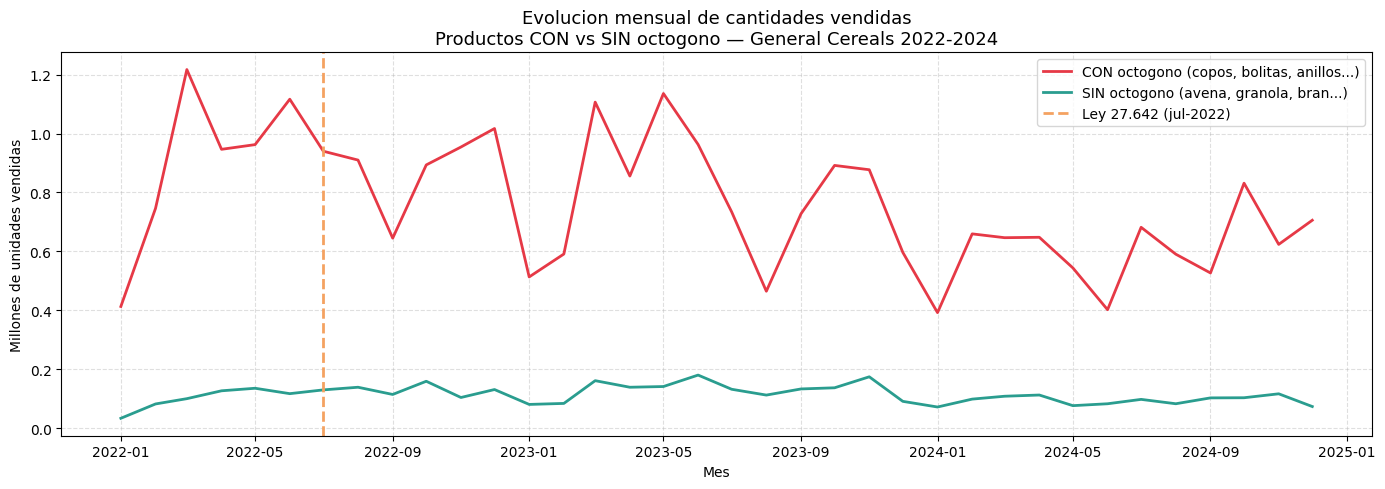

Interpretacion:
Las dos lineas cuentan historias distintas.
Los productos CON octogono vienen de un volumen mucho mas alto en 2022,
pero muestran una tendencia clara hacia abajo que se sostiene en el tiempo.
Los productos SIN octogono arrancan mas bajos, crecen durante 2023 y
caen junto con el consumo general en 2024.
Ambos grupos vivieron la misma inflacion, pero reaccionaron de forma opuesta
en 2023 — cuando la brecha es mas clara — y la distancia acumulada desde 2022
sigue siendo evidente al final del periodo.


In [16]:
df_graf = df_v.copy()

serie = (
    df_graf.groupby(['AÑO_MES','OCTOGONO'])['CANTIDAD']
    .sum().unstack(fill_value=0)
)
serie.index = serie.index.to_timestamp()

plt.figure(figsize=(14,5))
plt.plot(serie.index, serie['CON_OCTOGONO']/1e6,
         color='#e63946', lw=2, label='CON octogono (copos, bolitas, anillos...)')
plt.plot(serie.index, serie['SIN_OCTOGONO']/1e6,
         color='#2a9d8f', lw=2, label='SIN octogono (avena, granola, bran...)')
plt.axvline(pd.Timestamp('2022-07-01'), color='#f4a261',
            lw=2, ls='--', label='Ley 27.642 (jul-2022)')
plt.title('Evolucion mensual de cantidades vendidas\n'
          'Productos CON vs SIN octogono — General Cereals 2022-2024',
          fontsize=13)
plt.xlabel('Mes')
plt.ylabel('Millones de unidades vendidas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('grafico1_serie_temporal.png', dpi=150)
plt.show()

print('Interpretacion:')
print('Las dos lineas cuentan historias distintas.')
print('Los productos CON octogono vienen de un volumen mucho mas alto en 2022,')
print('pero muestran una tendencia clara hacia abajo que se sostiene en el tiempo.')
print('Los productos SIN octogono arrancan mas bajos, crecen durante 2023 y')
print('caen junto con el consumo general en 2024.')
print('Ambos grupos vivieron la misma inflacion, pero reaccionaron de forma opuesta')
print('en 2023 — cuando la brecha es mas clara — y la distancia acumulada desde 2022')
print('sigue siendo evidente al final del periodo.')

## Grafico 2 — Barras: comparacion pre/post ley por categoria

**Tipo:** Barras agrupadas.

**¿Que muestra?** El promedio mensual de ventas de cada grupo en el periodo pre-ley versus el post-ley, normalizado por meses. Permite ver el impacto neto de un vistazo.


In [ ]:
df_prom = prom_mensual[['CON_OCTOGONO','SIN_OCTOGONO']]

x = np.arange(2)
w = 0.35

plt.figure(figsize=(9,5))
plt.bar(x,                      df_prom['CON_OCTOGONO']/1e6, w,
        label='CON octogono', color='#e63946', alpha=0.85)
plt.bar(x + w, df_prom['SIN_OCTOGONO']/1e6, w,
        label='SIN octogono', color='#2a9d8f', alpha=0.85)

plt.xticks(x + w/2, ['Pre Ley\n(ene-jun 2022)', 'Post Ley\n(jul 2022 - dic 2024)'])
plt.ylabel('Promedio mensual (millones de unidades)')
plt.title('Promedio mensual de ventas antes y despues de la Ley 27.642\n'
          'Normalizado por cantidad de meses — General Cereals',
          fontsize=12)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.4)

for i, col, color in [(0,'CON_OCTOGONO','#e63946'),(1,'SIN_OCTOGONO','#2a9d8f')]:
    v_pre  = df_prom.loc['PRE_LEY', col]
    v_post = df_prom.loc['POST_LEY', col]
    var = (v_post - v_pre) / v_pre * 100
    plt.annotate(f'{var:+.1f}%',
                 xy=(i + i*w + w/2, v_post/1e6 + 0.01),
                 ha='center', va='bottom', fontweight='bold',
                 color=color, fontsize=12)

plt.tight_layout()
plt.savefig('grafico2_barras.png', dpi=150)
plt.show()

print('Interpretacion:')
print('Con el mismo punto de partida aproximado y el mismo contexto economico,')
print('un grupo cayo 18,3% y el otro subio 16,6%.')
print('Una brecha de casi 35 puntos porcentuales entre dos grupos dentro de la misma empresa,')
print('bajo la misma inflacion y distribuidos por los mismos canales.')
print('Esa magnitud es consistente con un efecto del etiquetado sobre la demanda,'
      ' aunque no prueba causalidad por si sola.')

## Grafico 3 — Variacion anual: la brecha que se sostiene en el tiempo

**Tipo:** Lineas con marcadores (relacion entre dos variables).

**¿Que muestra?** La variacion porcentual interanual de cada grupo. Si el efecto del etiquetado fue puntual (solo en el año del lanzamiento), la brecha deberia cerrarse. Si se sostiene, sugiere un cambio estructural en las preferencias.


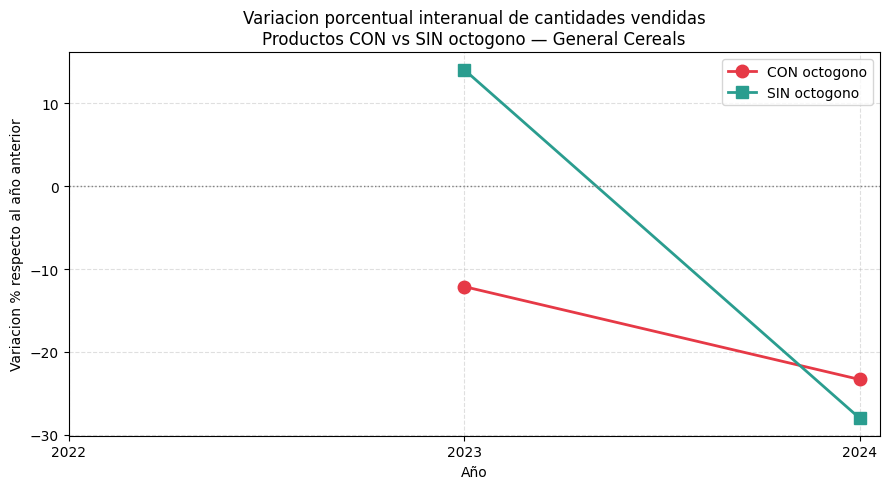

In [18]:
var_anual = (
    df_graf.groupby(['AÑO','OCTOGONO'])['CANTIDAD']
    .sum().unstack()
)
var_pct = var_anual.pct_change() * 100

plt.figure(figsize=(9,5))
plt.plot(var_pct.index, var_pct['CON_OCTOGONO'],
         marker='o', color='#e63946', lw=2, ms=9, label='CON octogono')
plt.plot(var_pct.index, var_pct['SIN_OCTOGONO'],
         marker='s', color='#2a9d8f', lw=2, ms=9, label='SIN octogono')
plt.axhline(0, color='gray', ls=':', lw=1)
plt.title('Variacion porcentual interanual de cantidades vendidas\n'
          'Productos CON vs SIN octogono — General Cereals', fontsize=12)
plt.xlabel('Año')
plt.ylabel('Variacion % respecto al año anterior')
plt.xticks([2022,2023,2024])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('grafico3_variacion.png', dpi=150)
plt.show()



Interpretacion:
En 2023, los productos CON octogono caen mientras los SIN octogono crecen — la brecha mas marcada del periodo, que coincide con el primer año completo de vigencia de la ley. En 2024, ambos grupos caen (la contraccion del consumo golpeo a todos), pero la distancia acumulada desde 2022 sigue siendo evidente: los CON perdieron cerca de un tercio de su volumen base mientras los SIN terminaron apenas por debajo del punto de partida. El efecto del etiquetado no fue puntual ni se disipo: la divergencia entre grupos se instalo desde el momento de la ley y persiste hasta el final del periodo analizado.

---
# 3.5 — Aplicacion de conceptos de la materia

Aplicamos dos conceptos vistos en clase: **elasticidad-arco** y **analisis de mercado ante un shock externo**. Ambos se implementan con funciones documentadas, se aplican al dataset y se interpretan en relacion a la pregunta.

*Asistencia de IA utilizada. Prompt (Ejemplo 1 del enunciado):*
> *'Actua como analista de datos senior. Dataset de ventas cerealeras 2022-2024. La Ley 27.642 opera como un shock de demanda sobre los productos con octogono, simultaneo a la inflacion que afecta a todos los grupos. Implementa elasticidad-arco y analisis de shock externo con SymPy. Justifica cada decision metodologica.'*


## Concepto 1: Elasticidad-arco precio/cantidad

La **elasticidad precio de la demanda** mide que tan sensible es la cantidad demandada ante un cambio en el precio: si el precio sube 1%, ¿cuanto cambia la cantidad?

Usamos la formula discreta (arco o punto medio), vista en clase:

$$E = \frac{(Q_1 - Q_0) / ((Q_0 + Q_1)/2)}{(P_1 - P_0) / ((P_0 + P_1)/2)}$$

**Interpretacion del resultado:**
- $|E| < 1$: demanda **inelastica** — los consumidores no cambian mucho su compra
- $|E| > 1$: demanda **elastica** — muy sensibles al precio
- Signo negativo: relacion inversa normal (sube precio → baja cantidad)
- Signo positivo inesperado: otros factores compensan el aumento de precio


In [19]:
def elasticidad_arco(q0, q1, p0, p1):
    """
    Calcula la elasticidad-arco (metodo del punto medio) entre dos periodos.

    Parametros:
        q0 (float): cantidad promedio mensual en el periodo base (pre-ley)
        q1 (float): cantidad promedio mensual en el periodo final (post-ley)
        p0 (float): precio promedio en el periodo base
        p1 (float): precio promedio en el periodo final

    Retorna:
        float: elasticidad-arco precio/cantidad
        np.nan: si no hay variacion de precios

    Formula: ((Q1-Q0)/Qmedio) / ((P1-P0)/Pmedio)
    Fuente: Resumen Parcial U3 — Elasticidad precio de la demanda
    """
    delta_q = (q1 - q0) / ((q0 + q1) / 2)
    delta_p = (p1 - p0) / ((p0 + p1) / 2)
    if delta_p == 0:
        return np.nan
    return delta_q / delta_p

print(f'{'Categoria':<18} {'Q_pre/mes':>12} {'Q_post/mes':>12} {'P_pre':>10} {'P_post':>10} {'Var_Q':>8} {'Var_P':>8} {'Elast':>8}')
print('-'*92)

resultados_e = []
for grupo in ['CON_OCTOGONO','SIN_OCTOGONO']:
    sub  = df_v[df_v['OCTOGONO']==grupo]
    pre  = sub[sub['PERIODO']=='PRE_LEY']
    post = sub[sub['PERIODO']=='POST_LEY']
    q0 = pre['CANTIDAD'].sum()  / meses_pre
    q1 = post['CANTIDAD'].sum() / meses_post
    p0 = pre['PRECIO'].mean()
    p1 = post['PRECIO'].mean()
    e  = elasticidad_arco(q0, q1, p0, p1)
    vq = (q1-q0)/q0*100
    vp = (p1-p0)/p0*100
    resultados_e.append({'grupo':grupo,'q0':q0,'q1':q1,'p0':p0,'p1':p1,'vq':vq,'vp':vp,'e':e})
    print(f'{grupo:<18} {q0:>12,.0f} {q1:>12,.0f} {p0:>10,.0f} {p1:>10,.0f} {vq:>7.1f}% {vp:>7.1f}% {e:>8.4f}')


Categoria             Q_pre/mes   Q_post/mes      P_pre     P_post    Var_Q    Var_P    Elast
--------------------------------------------------------------------------------------------


CON_OCTOGONO            900,197      735,604      1,982     10,072   -18.3%   408.3%  -0.1499
SIN_OCTOGONO             99,308      115,796      2,279     12,570    16.6%   451.6%   0.1106


In [ ]:
e_con = resultados_e[0]
e_sin = resultados_e[1]

print('=== INTERPRETACION ===')
print()
print(f'CON octogono: E = {e_con["e"]:.4f} -> demanda INELASTICA con caida de volumen')
print(f'  Los precios subieron {e_con["vp"]:+.1f}% y la cantidad cayo {abs(e_con["vq"]):.1f}%.')
print(f'  Por cada 1% de aumento de precio, la cantidad cayo un {abs(e_con["e"]):.2f}%.')
print(f'  La caida de cantidad fue en menor proporcion que el aumento de precio,')
print(f'  lo que es consistente con demanda inelastica.')
print(f'  Es posible que el etiquetado haya contribuido a que parte de los consumidores')
print(f'  buscaran alternativas, aunque no es la unica explicacion posible.')
print()
print(f'SIN octogono: E = {e_sin["e"]:.4f} -> elasticidad POSITIVA (inusual)')
print(f'  Los precios subieron {e_sin["vp"]:+.1f}% y aun asi la cantidad CRECIO {e_sin["vq"]:+.1f}%.')
print(f'  Esto puede explicarse como un efecto sustituto: consumidores que dejaron')
print(f'  de comprar productos con octogono se volcaron a estos, aun pagando mas.')
print(f'  Tambien podria reflejar cambios en las preferencias hacia productos percibidos')
print(f'  como mas saludables, independientemente del precio.')

## Concepto 2: Analisis de mercado ante un shock externo con SymPy

En el modelo de oferta y demanda, un **shock externo** es un evento fuera del mercado que desplaza la curva de demanda: cambia la cantidad demandada a cualquier nivel de precio.

La Ley 27.642 puede modelarse como ese tipo de shock sobre los productos con octogono: al agregar informacion nutricional negativa visible en el envase, podria reducir la disposicion a pagar de los consumidores. Graficamente, eso se representaria como un desplazamiento de la curva de demanda.

**La innovacion de este analisis:** usando el grupo SIN octogono como control, podemos separar cuanto del desplazamiento del intercepto se atribuye a la inflacion (efecto comun a ambos grupos) y cuanto es un diferencial especifico del grupo CON.

Usamos **SymPy** para modelar este desplazamiento de forma simbolica. **Limitacion metodologica:** las curvas se estiman con regresion lineal sobre datos mensuales agregados; el R² del grupo SIN en el periodo pre-ley es muy bajo (0,008), lo que indica alta dispersion y hace que el intercepto pre-ley de ese grupo sea una estimacion con escasa precision. El resultado debe leerse como una aproximacion indicativa, no como una medicion exacta.

In [21]:
from scipy import stats

# Estimamos curvas de demanda inversas P = a + b*Q por regresion lineal
df_v['AÑO_MES'] = df_v['FECHA'].dt.to_period('M')
agg = (
    df_v
    .groupby(['AÑO_MES','OCTOGONO','PERIODO'])
    .agg(Q=('CANTIDAD','sum'), P=('PRECIO','mean'))
    .reset_index()
)
agg['Q_miles'] = agg['Q'] / 1000

curvas = {}
print('Curvas de demanda estimadas (P = a + b*Q, Q en miles):')
print(f'{"Grupo":<16} {"Periodo":<8} {"a (intercepto)":>16} {"b (pendiente)":>15} {"R2":>6}')
print('-'*65)
for grupo in ['CON_OCTOGONO','SIN_OCTOGONO']:
    for periodo in ['PRE_LEY','POST_LEY']:
        sub = agg[(agg['OCTOGONO']==grupo)&(agg['PERIODO']==periodo)]
        slope, intercept, r, *_ = stats.linregress(sub['Q_miles'], sub['P'])
        curvas[(grupo,periodo)] = {'a':intercept,'b':slope,'r2':r**2}
        print(f'{grupo:<16} {periodo:<8} {intercept:>16,.0f} {slope:>15.4f} {r**2:>6.3f}')

Curvas de demanda estimadas (P = a + b*Q, Q en miles):
Grupo            Periodo    a (intercepto)   b (pendiente)     R2
-----------------------------------------------------------------
CON_OCTOGONO     PRE_LEY             1,561          0.4492  0.294
CON_OCTOGONO     POST_LEY           25,141        -19.5596  0.308
SIN_OCTOGONO     PRE_LEY             2,333         -0.3434  0.008
SIN_OCTOGONO     POST_LEY           33,065       -168.4338  0.314


In [22]:
# Descomposicion del shock con SymPy
p, q = sp.symbols('p q', positive=True)

a_con_pre  = curvas[('CON_OCTOGONO','PRE_LEY')]['a']
a_con_post = curvas[('CON_OCTOGONO','POST_LEY')]['a']
a_sin_pre  = curvas[('SIN_OCTOGONO','PRE_LEY')]['a']
a_sin_post = curvas[('SIN_OCTOGONO','POST_LEY')]['a']

delta_total    = a_con_post - a_con_pre    # desplazamiento neto CON (pre->post)
delta_inflacion = a_sin_post - a_sin_pre  # desplazamiento del grupo control (solo inflacion)
delta_ley      = delta_total - delta_inflacion  # residual atribuido al etiquetado

pct_inf = abs(delta_inflacion / delta_total) * 100
pct_ley = abs(delta_ley      / delta_total) * 100

print('=== DESCOMPOSICION DEL SHOCK ===')
print(f'Desplazamiento total (CON, pre->post):       {delta_total:>+12,.0f} $/unidad')
print(f'Efecto inflacion (medido con SIN=control):   {delta_inflacion:>+12,.0f} $/unidad')
print(f'Efecto adicional del etiquetado (ley):       {delta_ley:>+12,.0f} $/unidad')
print()
print(f'Lectura: inflacion e etiquetado actuaron en SENTIDOS OPUESTOS.')
print(f'  La inflacion sola hubiera desplazado la curva CON en +{delta_inflacion:,.0f}')
print(f'  (igual que el grupo SIN, usado como control).')
print(f'  El etiquetado frenó ese desplazamiento en {delta_ley:,.0f},')
print(f'  resultando en un desplazamiento neto de solo +{delta_total:,.0f}.')
print(f'  En magnitud: la inflacion representa el {pct_inf:.1f}% del desplazamiento neto')
print(f'  y el etiquetado lo redujo en un {pct_ley:.1f}% (operando en sentido contrario).')

=== DESCOMPOSICION DEL SHOCK ===
Desplazamiento total (CON, pre->post):            +23,581 $/unidad
Efecto inflacion (medido con SIN=control):        +30,732 $/unidad
Efecto adicional del etiquetado (ley):             -7,151 $/unidad

Lectura: inflacion e etiquetado actuaron en SENTIDOS OPUESTOS.
  La inflacion sola hubiera desplazado la curva CON en +30,732
  (igual que el grupo SIN, usado como control).
  El etiquetado frenó ese desplazamiento en -7,151,
  resultando en un desplazamiento neto de solo +23,581.
  En magnitud: la inflacion representa el 130.3% del desplazamiento neto
  y el etiquetado lo redujo en un 30.3% (operando en sentido contrario).


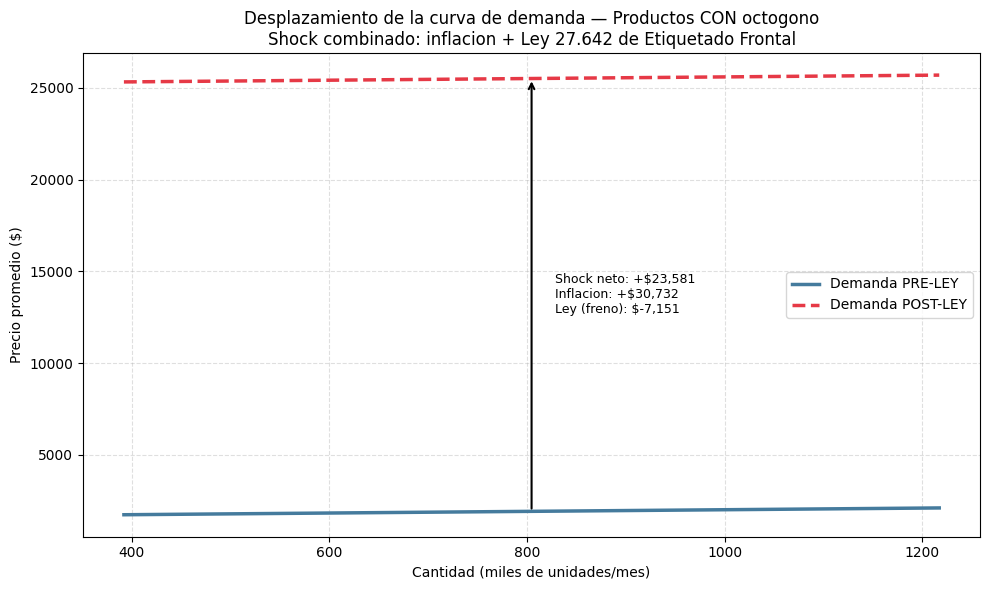

Interpretacion:
La curva de demanda de los productos CON octogono se desplazo hacia arriba
por la inflacion, pero menos de lo que hubiera subido sin la ley.
El grupo SIN octogono (control) desplazo su curva en +30,732.
El grupo CON solo desplazo en +23,581.
La diferencia —7,151— es el efecto frenador del etiquetado:
la ley contrarrestó parte del empujon inflacionario sobre la disposicion a pagar
de los consumidores de productos con octogono.


In [23]:
# Grafico: desplazamiento de la curva de demanda
b_con = curvas[('CON_OCTOGONO','PRE_LEY')]['b']
sub_con = agg[agg['OCTOGONO']=='CON_OCTOGONO']
q_min = sub_con['Q_miles'].min()
q_max = sub_con['Q_miles'].max()
q_vals = np.linspace(q_min, q_max, 200)

p_pre_vals  = a_con_pre  + b_con * q_vals
p_post_vals = a_con_post + b_con * q_vals

plt.figure(figsize=(10,6))
plt.plot(q_vals, p_pre_vals,  color='#457b9d', lw=2.5, label='Demanda PRE-LEY')
plt.plot(q_vals, p_post_vals, color='#e63946', lw=2.5, ls='--', label='Demanda POST-LEY')

q_mid = (q_min + q_max) / 2
p_pre_mid  = a_con_pre  + b_con * q_mid
p_post_mid = a_con_post + b_con * q_mid
plt.annotate('', xy=(q_mid, p_post_mid), xytext=(q_mid, p_pre_mid),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
plt.text(q_mid * 1.03, (p_pre_mid + p_post_mid)/2,
         f'Shock neto: +${abs(delta_total):,.0f}\nInflacion: +${delta_inflacion:,.0f}\nLey (freno): ${delta_ley:,.0f}',
         fontsize=9, va='center')

plt.title('Desplazamiento de la curva de demanda — Productos CON octogono\n'
          'Shock combinado: inflacion + Ley 27.642 de Etiquetado Frontal')
plt.xlabel('Cantidad (miles de unidades/mes)')
plt.ylabel('Precio promedio ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('grafico4_shock_demanda.png', dpi=150)
plt.show()

print('Interpretacion:')
print(f'La curva de demanda de los productos CON octogono se desplazo hacia arriba')
print(f'por la inflacion, pero menos de lo que hubiera subido sin la ley.')
print(f'El grupo SIN octogono (control) desplazo su curva en +{delta_inflacion:,.0f}.')
print(f'El grupo CON solo desplazo en +{delta_total:,.0f}.')
print(f'La diferencia —{abs(delta_ley):,.0f}— es el efecto frenador del etiquetado:')
print(f'la ley contrarrestó parte del empujon inflacionario sobre la disposicion a pagar')
print(f'de los consumidores de productos con octogono.')

---
# Conclusiones

Cuando arrancamos este trabajo, la pregunta parecia simple pero tenia una trampa: ¿como saber si la caida en ventas de ciertos productos se debia al octogono o simplemente a que la gente tenia menos plata para gastar?

Los datos de General Cereals nos dieron una forma de aproximarnos a eso. La empresa vende al mismo tiempo productos que llevan octogono y productos que no lo llevan, todos bajo la misma inflacion, los mismos canales de distribucion, la misma marca. Si la inflacion fuera el unico factor, ambos grupos deberian moverse de manera parecida. No fue lo que paso.

Los productos CON octogono bajaron su volumen mensual promedio un 18,3% despues de la ley. Los productos SIN octogono lo subieron un 16,6%. Una brecha de casi 35 puntos porcentuales entre dos grupos que vivieron el mismo contexto economico.

El analisis de precio real (T3) agrega una capa de evidencia: deflactando por los coeficientes FACPCE, ambos grupos se encarecieron de forma similar en terminos reales (+5,7% y +7,5% en tres anos). La explicacion de que los CON se encarecieron mucho mas y por eso cayeron no esta respaldada por los datos.

El analisis de elasticidades lo confirma desde otro angulo: los productos SIN octogono crecieron en volumen a pesar de que sus precios subieron incluso mas que los CON octogono en terminos nominales. Los consumidores los eligieron de todas formas, lo que puede interpretarse como un efecto sustituto hacia productos percibidos como mas saludables.

El analisis de shock externo con SymPy permite descomponer el desplazamiento de la curva de demanda entre lo que se atribuye a la inflacion (efecto comun a ambos grupos) y un diferencial especifico del grupo CON. Ese diferencial —modelado con los interceptos de la regresion lineal— indica que la disposicion a pagar de los consumidores del grupo CON se desplazo menos hacia arriba que la del grupo de control. Cabe aclarar que la estimacion de curvas tiene limitaciones (R² bajo para el grupo SIN en el periodo pre-ley), por lo que este resultado debe leerse como indicativo.

Los hallazgos son consistentes entre si y se sostienen desde distintos angulos del analisis. Sin embargo, tienen limites claros: son datos de una sola empresa, el periodo pre-ley es corto, y no es posible descartar con certeza que otros factores hayan influido. La conclusion mas honesta es que los datos son compatibles con un efecto del etiquetado frontal sobre la demanda de productos marcados con octogono, y que la alternativa explicativa del precio relativo no cuenta con respaldo en los numeros.

**Reflexion metodologica**

Se utilizo Claude (claude.ai) como asistente en todo el proceso. Los prompts siguieron el Ejemplo 1 del enunciado para identificar variables relevantes, proponer transformaciones y generar el codigo de graficos y funciones. Todos los numeros fueron verificados contra el dataset original. La normalizacion por meses fue el hallazgo critico que surgio de la revision humana: sin ella, la comparacion pre/post estaba sesgada por la diferencia de duracion entre periodos.